# Day 3 — Dimensionality Reduction with PCA



##  step 1- Data Preparation

PCA is applied to the scaled numerical features of the Cardiac Patients dataset.

Feature scaling is required because PCA is based on variance, and features with larger numerical ranges could otherwise have a greater influence on the resulting principal components.

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

df = pd.read_csv(
    r"C:\Users\Hp\Desktop\binx_mohammadabuhamed\binx_mohammadabuhamed\Cardiac Patients\data\dataprocessed_heart_data.csv"
)
X = df.drop("has_heart_disease", axis=1)
X_numeric = X.select_dtypes(include="number")
X_scaled=StandardScaler().fit_transform(X_numeric)

## Step 2- Fit PCA



PCA is applied to the scaled data to create new features called **Principal Components**.

Each Principal Component is a combination of the original features, and the components are ordered based on how much variance they capture.

At this stage, `n_components` is not specified because we want PCA to calculate all available components so we can examine the explained variance and decide how many components should be kept.

In [4]:
from sklearn.decomposition import PCA
pca=PCA()
X_pca=pca.fit(X_scaled)

### Explained Variance Ratio for Each Principal Component

In [5]:
print(pca.explained_variance_ratio_)

[0.16165568 0.0907245  0.07925986 0.07393808 0.06255891 0.05516533
 0.05047894 0.04779952 0.0455491  0.04486229 0.04124949 0.0395539
 0.03763937 0.03554665 0.0352022  0.02458641 0.02402902 0.02235896
 0.01113668 0.00976609 0.00553991 0.0013991 ]


### Calculate the Cumulative Explained Variance

In [6]:
import numpy as np

cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)

print(cumulative_variance)

[0.16165568 0.25238018 0.33164004 0.40557813 0.46813704 0.52330237
 0.57378131 0.62158083 0.66712993 0.71199222 0.75324171 0.79279561
 0.83043498 0.86598163 0.90118383 0.92577024 0.94979926 0.97215822
 0.9832949  0.99306099 0.9986009  1.        ]


### Plot the Cumulative Explained Variance

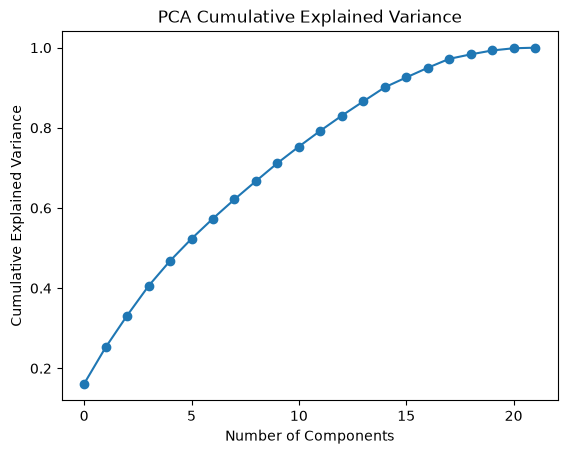

In [11]:
import matplotlib.pyplot as plt
plt.plot(
    cumulative_variance,
    marker="o"
)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.show()


PCA was fitted to the scaled dataset to analyze how much variance is preserved by different numbers of Principal Components.

The cumulative explained variance increases as more components are included.

From the results, approximately 95% of the total variance can be preserved using around 17 Principal Components.

## step 3-  Reduce the Data to 17 Principal Components

In [12]:
pca_17 = PCA(n_components=17)

X_pca_17 = pca_17.fit_transform(X_scaled)

print(pca_17.explained_variance_ratio_.sum())

0.9497992559150109



17 Principal Components were selected because they preserve approximately **95% of the total variance** in the original data.

This reduces the dataset from **22 dimensions to 17 dimensions** while retaining most of the information contained in the original features.

## Step 4- Reduce Data to 2 Components and plot it

### Reduce the Data to Two Principal Components

In [13]:
pca_2 = PCA(n_components=2)

X_pca_2 = pca_2.fit_transform(X_scaled)

### Explained Variance of the First Two Components

In [14]:
print(pca_2.explained_variance_ratio_)
print(pca_2.explained_variance_ratio_.sum())

[0.16165568 0.0907245 ]
0.25238018094986897


### Visualize the Data Using the First Two Principal Components

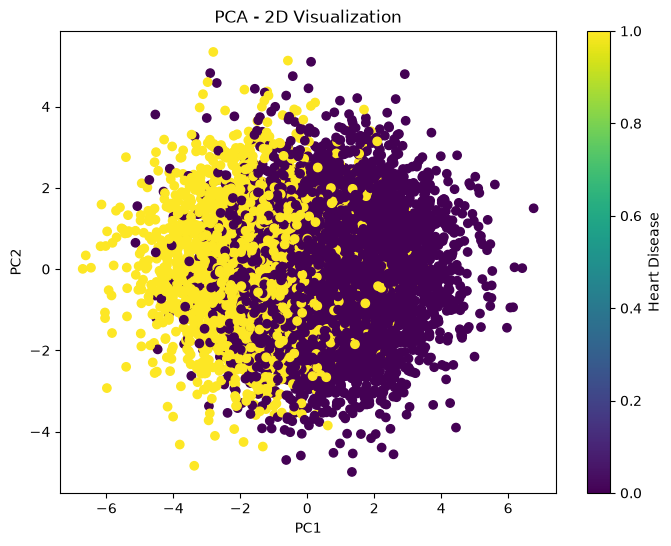

In [17]:
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_pca_2[:, 0],
    X_pca_2[:, 1],
    c=df["has_heart_disease"]
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA - 2D Visualization")

plt.colorbar(scatter, label="Heart Disease")

plt.show()



The first two Principal Components preserve approximately **25.24% of the total variance**.

The visualization shows some separation between patients with and without heart disease, mainly along PC1. However, there is still considerable overlap between the two groups.

Therefore, the first two components reveal some structure in the data, but they do not fully represent the original dataset.

## Step 5 — PCA Reduction Analysis

PCA reduced the original dataset from **22 features to 17 Principal Components** while preserving approximately **95% of the total variance**.

This means that most of the information and variation in the original data was retained using fewer dimensions.

For visualization, the dataset was further reduced to **2 Principal Components**. These two components preserved approximately **25.24% of the total variance**, allowing the high-dimensional dataset to be visualized in a 2D scatter plot.

### What PCA Preserved

- Approximately **95% of the variance** was preserved using 17 components.
- The main patterns and variation in the original features were largely retained.
- PCA provided a lower-dimensional representation of the dataset.

### What PCA Cost

- The Principal Components are combinations of the original features, making them harder to interpret directly.
- Reducing the data to only 2 components preserved only **25.24% of the total variance**.
- Therefore, the 2D visualization does not represent all the information contained in the original dataset.

### Conclusion

PCA provided a useful trade-off between dimensionality and information retention. Using 17 components preserved most of the original variance, while using 2 components made visualization possible at the cost of losing a significant amount of information.